# Annual maxima 的 stationary GEV 檢查

目的：檢查 1980--2024 的 45 個年最大值是否適合使用固定的 GEV 參數。分析只比較 location 是否隨時間改變；scale 與 shape 暫時固定。

In [1]:
from pathlib import Path
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from joblib import Parallel, delayed
from scipy.optimize import minimize
from scipy.stats import chi2, genextreme, linregress

CURRENT = Path.cwd().resolve()
PROJECT_ROOT = CURRENT if (CURRENT / 'src').exists() else CURRENT.parent
ANNUAL_PATH = PROJECT_ROOT / 'data' / 'processed' / 'annual_max_grid_temperature.csv'
GRID_PATH = PROJECT_ROOT / 'data' / 'processed' / 'model_ready_grid_parameters.csv'
TABLE_PATH = PROJECT_ROOT / 'results' / 'tables' / 'temporal_stationarity_gev_grid_results.csv'
FIGURE_PATH = PROJECT_ROOT / 'results' / 'figures' / 'grill_stationarity_diagnostics.png'

N_JOBS = int(os.environ.get('GRILL_N_JOBS', '-2'))
MAX_GRIDS = int(os.environ.get('GRILL_MAX_GRIDS', '0')) or None
TABLE_PATH.parent.mkdir(parents=True, exist_ok=True)
FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT =', PROJECT_ROOT)
print('N_JOBS =', N_JOBS, '| MAX_GRIDS =', MAX_GRIDS)

PROJECT_ROOT = C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast parameter estimate\fast_parameter_using_NN
N_JOBS = -2 | MAX_GRIDS = None


## 比較方法

Stationary model：
$$Y_t\sim\mathrm{GEV}(\mu_0,\sigma,\xi).$$

Nonstationary-location model：
$$Y_t\sim\mathrm{GEV}(\mu_0+\mu_1t_c,\sigma,\xi),$$
其中 $t_c$ 以 decade 為單位，因此 $\mu_1$ 是每十年的溫度變化。每個 GRID 比較 $\Delta\mathrm{AICc}=\mathrm{AICc}_{stationary}-\mathrm{AICc}_{trend}$；正值支持 trend model。LRT 的 $p$ 值再以 Benjamini--Hochberg FDR 修正。

In [2]:
annual_wide = pd.read_csv(ANNUAL_PATH)
grid = pd.read_csv(GRID_PATH)[['station', 'x_km', 'y_km', 'lat', 'lon']].copy()

annual_wide = annual_wide.loc[annual_wide['year'].between(1980, 2024)].copy()
stations = [station for station in grid['station'] if station in annual_wide.columns]
if MAX_GRIDS is not None:
    stations = stations[:MAX_GRIDS]
grid = grid.loc[grid['station'].isin(stations)].copy()

assert annual_wide['year'].nunique() == 45, '預期 1980--2024 共 45 年。'
assert len(stations) > 0, '找不到可分析的 GRID。'

years = annual_wide['year'].to_numpy(float)
temperature = annual_wide[stations].to_numpy(float)
print(f'Years: {int(years.min())}--{int(years.max())}')
print(f'GRID count: {len(stations):,}')
print(f'Finite observations: {np.isfinite(temperature).sum():,}')

Years: 1980--2024
GRID count: 1,385
Finite observations: 62,325


In [3]:
def _finite_nll(logpdf):
    if not np.all(np.isfinite(logpdf)):
        return 1e12
    return float(-np.sum(logpdf))


def _stationary_nll(params, y):
    mu, log_sigma, xi = params
    sigma = np.exp(log_sigma)
    return _finite_nll(genextreme.logpdf(y, c=-xi, loc=mu, scale=sigma))


def _trend_nll(params, y, time_decades):
    mu0, slope_decade, log_sigma, xi = params
    mu_t = mu0 + slope_decade * time_decades
    sigma = np.exp(log_sigma)
    return _finite_nll(genextreme.logpdf(y, c=-xi, loc=mu_t, scale=sigma))


def _aicc(log_likelihood, n, k):
    aic = 2 * k - 2 * log_likelihood
    return aic + 2 * k * (k + 1) / (n - k - 1)


def _bounded_fit(objective, start, bounds, args):
    result = minimize(
        objective, start, args=args, method='L-BFGS-B', bounds=bounds,
        options={'maxiter': 500},
    )
    if result.success and np.isfinite(result.fun) and result.fun < 1e11:
        return result
    return minimize(
        objective, start, args=args, method='Powell', bounds=bounds,
        options={'maxiter': 1000},
    )


def fit_grid(station, y_all, year_all):
    valid = np.isfinite(y_all) & np.isfinite(year_all)
    y = np.asarray(y_all[valid], dtype=float)
    year = np.asarray(year_all[valid], dtype=float)
    n = len(y)
    if n < 20 or np.nanstd(y) <= 0:
        return {'station': station, 'n_obs': n, 'fit_success': False}

    time_decades = (year - year.mean()) / 10.0
    sample_sd = max(float(np.std(y, ddof=1)), 0.05)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        c0, loc0, scale0 = genextreme.fit(y)
    xi0 = float(np.clip(-c0, -0.45, 0.45))
    scale0 = max(float(scale0), 0.05)
    mu_bounds = (float(y.min() - 5 * sample_sd), float(y.max() + 5 * sample_sd))
    log_scale_bounds = (np.log(max(sample_sd * 0.02, 0.01)), np.log(sample_sd * 20))

    stationary = _bounded_fit(
        _stationary_nll,
        np.array([loc0, np.log(scale0), xi0]),
        [mu_bounds, log_scale_bounds, (-0.5, 0.5)],
        (y,),
    )
    mu_s, log_sigma_s, xi_s = stationary.x
    slope_ols = float(np.clip(np.polyfit(time_decades, y, 1)[0], -5.0, 5.0))
    trend_bounds = [mu_bounds, (-5.0, 5.0), log_scale_bounds, (-0.5, 0.5)]
    trend_candidates = [
        _bounded_fit(
            _trend_nll,
            np.array([mu_s, initial_slope, log_sigma_s, xi_s]),
            trend_bounds,
            (y, time_decades),
        )
        for initial_slope in (0.0, slope_ols)
    ]
    trend = min(trend_candidates, key=lambda result: result.fun)
    # The trend model contains the stationary model at slope=0.  Numerical
    # optimization must therefore never return a lower maximized likelihood.
    if (not np.isfinite(trend.fun)) or trend.fun > stationary.fun:
        mu_t, slope_t, log_sigma_t, xi_t = mu_s, 0.0, log_sigma_s, xi_s
        ll_trend = -float(stationary.fun)
        trend_success = bool(stationary.success)
    else:
        mu_t, slope_t, log_sigma_t, xi_t = trend.x
        ll_trend = -float(trend.fun)
        trend_success = bool(trend.success)

    ll_stationary = -float(stationary.fun)
    lrt = max(0.0, 2.0 * (ll_trend - ll_stationary))
    aicc_stationary = _aicc(ll_stationary, n, 3)
    aicc_trend = _aicc(ll_trend, n, 4)
    return {
        'station': station,
        'n_obs': n,
        'fit_success': bool(stationary.success and trend_success),
        'mu_stationary': mu_s,
        'sigma_stationary': np.exp(log_sigma_s),
        'xi_stationary': xi_s,
        'mu0_trend': mu_t,
        'slope_c_per_decade': slope_t,
        'sigma_trend': np.exp(log_sigma_t),
        'xi_trend': xi_t,
        'loglik_stationary': ll_stationary,
        'loglik_trend': ll_trend,
        'aicc_stationary': aicc_stationary,
        'aicc_trend': aicc_trend,
        'delta_aicc': aicc_stationary - aicc_trend,
        'lrt_statistic': lrt,
        'lrt_p_value': chi2.sf(lrt, df=1),
    }


def benjamini_hochberg(p_values):
    p = np.asarray(p_values, dtype=float)
    adjusted = np.full(p.shape, np.nan)
    valid = np.isfinite(p)
    order = np.argsort(p[valid])
    ranked = p[valid][order]
    n = len(ranked)
    q_ranked = np.minimum.accumulate((ranked * n / np.arange(1, n + 1))[::-1])[::-1]
    q_sorted_back = np.empty(n)
    q_sorted_back[order] = np.clip(q_ranked, 0, 1)
    adjusted[valid] = q_sorted_back
    return adjusted

In [4]:
fit_rows = Parallel(
    n_jobs=N_JOBS,
    backend='loky',
    idle_worker_timeout=1800,
    verbose=5,
)(
    delayed(fit_grid)(station, temperature[:, column], years)
    for column, station in enumerate(stations)
)

results = pd.DataFrame(fit_rows)
results['lrt_q_value'] = benjamini_hochberg(results['lrt_p_value'])
results['fdr_significant_005'] = results['lrt_q_value'] < 0.05
results['trend_supported_aicc2'] = results['delta_aicc'] > 2
results = results.merge(grid, on='station', how='left', validate='one_to_one')
if MAX_GRIDS is None:
    results.to_csv(TABLE_PATH, index=False)
    print('Saved:', TABLE_PATH)
else:
    print('Smoke mode: table was not persisted.')

[Parallel(n_jobs=-2)]: Using backend LokyBackend with 11 concurrent workers.
[Parallel(n_jobs=-2)]: Done  50 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-2)]: Done 318 tasks      | elapsed:    3.6s
[Parallel(n_jobs=-2)]: Done 822 tasks      | elapsed:    6.7s


Saved: C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast parameter estimate\fast_parameter_using_NN\results\tables\temporal_stationarity_gev_grid_results.csv


[Parallel(n_jobs=-2)]: Done 1385 out of 1385 | elapsed:   10.3s finished


In [5]:
valid = results.loc[results['fit_success']].copy()
summary = pd.DataFrame(
    {
        'Statistic': [
            'Analyzed GRID',
            'Successful fits',
            'Median slope (C/decade)',
            'Positive slope (%)',
            'Delta AICc > 2 (%)',
            'LRT significant after FDR (%)',
        ],
        'Value': [
            len(results),
            len(valid),
            valid['slope_c_per_decade'].median(),
            100 * valid['slope_c_per_decade'].gt(0).mean(),
            100 * valid['trend_supported_aicc2'].mean(),
            100 * valid['fdr_significant_005'].mean(),
        ],
    }
)
display(summary.style.format({'Value': '{:.3f}'}))

,Statistic,Value
0,Analyzed GRID,1385.000
1,Successful fits,1385.000
2,Median slope (C/decade),0.080
3,Positive slope (%),63.682
4,Delta AICc > 2 (%),41.444
5,LRT significant after FDR (%),32.852


## 本次完整檢定結果（1980--2024）

| 指標 | 結果 |
|---|---:|
| 成功配適 | 1,385 / 1,385 GRID |
| location trend 中位數 | 0.081 °C/decade |
| 正趨勢 GRID | 63.7% |
| $\Delta\mathrm{AICc}>2$ | 41.4% |
| LRT 經 BH-FDR 後顯著 | 32.9% |

判讀：有相當比例的 GRID 支持 location 隨時間改變，因此 stationary GEV 不宜直接視為已成立；論文應將 stationary 與 nonstationary-location 結果並列為敏感度分析。

## 圖形

左上角使用 overlay：觀測年度中位數、10--90% GRID 範圍、stationary 水平線與線性趨勢線放在同一座標。這裡不使用 stacked area/bar，因為兩個模型不是可相加的組成。

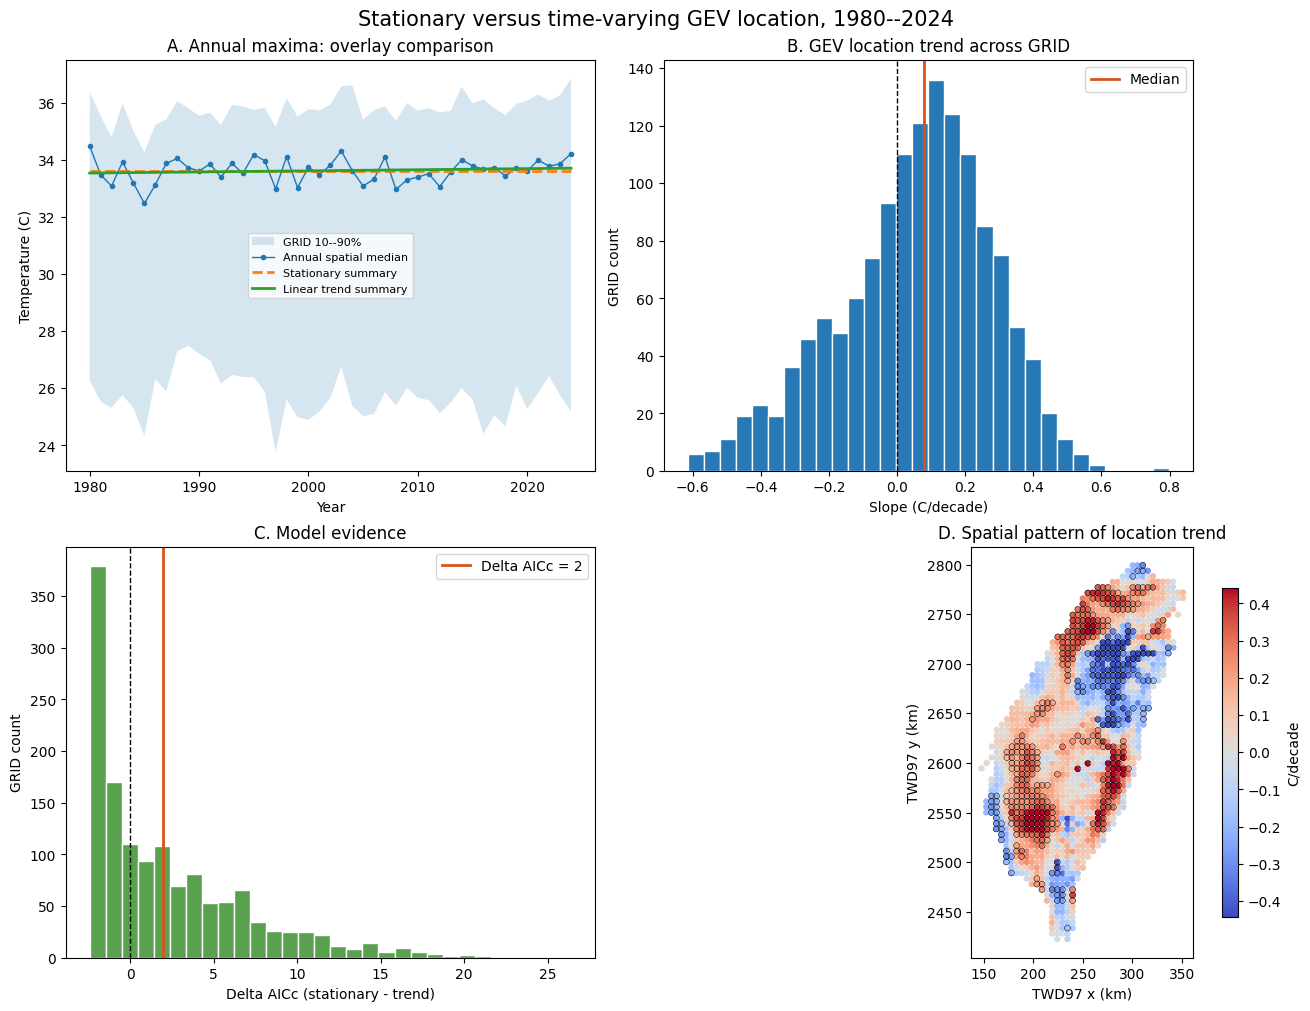

Saved: C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast parameter estimate\fast_parameter_using_NN\results\figures\grill_stationarity_diagnostics.png


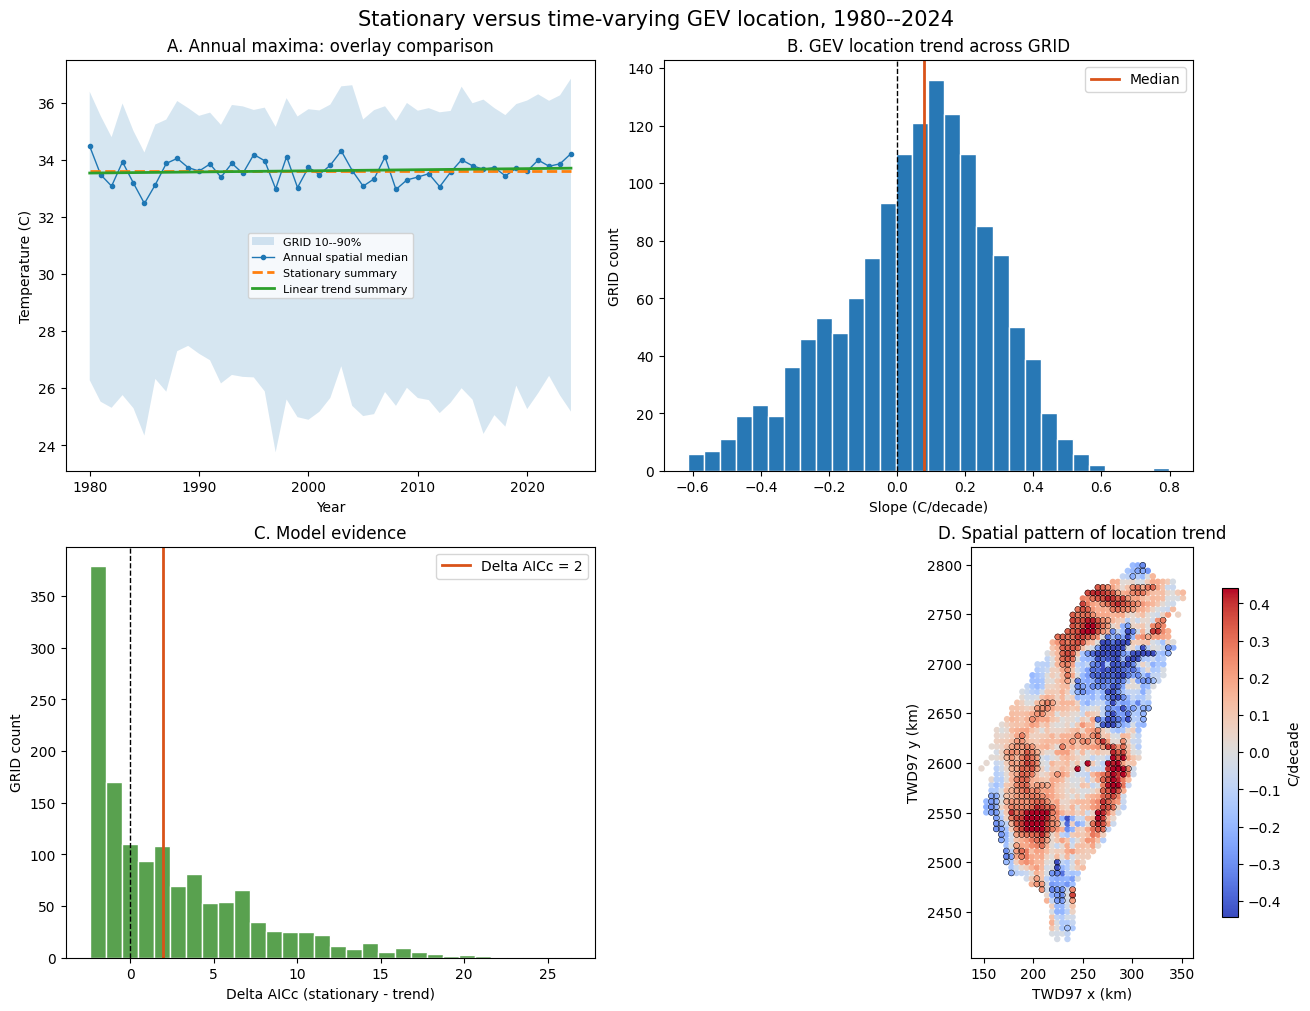

In [6]:
year_summary = pd.DataFrame(
    {
        'year': years,
        'q10': np.nanquantile(temperature, 0.10, axis=1),
        'median': np.nanmedian(temperature, axis=1),
        'q90': np.nanquantile(temperature, 0.90, axis=1),
    }
)
aggregate_trend = linregress(year_summary['year'], year_summary['median'])
trend_line = aggregate_trend.intercept + aggregate_trend.slope * year_summary['year']
stationary_line = np.repeat(year_summary['median'].mean(), len(year_summary))

fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)

ax = axes[0, 0]
ax.fill_between(year_summary['year'], year_summary['q10'], year_summary['q90'], alpha=0.18, label='GRID 10--90%')
ax.plot(year_summary['year'], year_summary['median'], 'o-', ms=3, lw=1, label='Annual spatial median')
ax.plot(year_summary['year'], stationary_line, '--', lw=2, label='Stationary summary')
ax.plot(year_summary['year'], trend_line, lw=2, label='Linear trend summary')
ax.set(title='A. Annual maxima: overlay comparison', xlabel='Year', ylabel='Temperature (C)')
ax.legend(fontsize=8)

ax = axes[0, 1]
ax.hist(valid['slope_c_per_decade'], bins=30, color='#2878B5', edgecolor='white')
ax.axvline(0, color='black', ls='--', lw=1)
ax.axvline(valid['slope_c_per_decade'].median(), color='#D95319', lw=2, label='Median')
ax.set(title='B. GEV location trend across GRID', xlabel='Slope (C/decade)', ylabel='GRID count')
ax.legend()

ax = axes[1, 0]
ax.hist(valid['delta_aicc'], bins=30, color='#59A14F', edgecolor='white')
ax.axvline(0, color='black', ls='--', lw=1)
ax.axvline(2, color='#D95319', lw=2, label='Delta AICc = 2')
ax.set(title='C. Model evidence', xlabel='Delta AICc (stationary - trend)', ylabel='GRID count')
ax.legend()

ax = axes[1, 1]
points = ax.scatter(
    valid['x_km'], valid['y_km'], c=valid['slope_c_per_decade'],
    s=13, cmap='coolwarm', vmin=-np.nanquantile(abs(valid['slope_c_per_decade']), 0.95),
    vmax=np.nanquantile(abs(valid['slope_c_per_decade']), 0.95),
)
significant = valid['fdr_significant_005']
ax.scatter(valid.loc[significant, 'x_km'], valid.loc[significant, 'y_km'], s=18, facecolors='none', edgecolors='black', linewidths=0.35)
ax.set(title='D. Spatial pattern of location trend', xlabel='TWD97 x (km)', ylabel='TWD97 y (km)', aspect='equal')
fig.colorbar(points, ax=ax, label='C/decade', shrink=0.8)

fig.suptitle('Stationary versus time-varying GEV location, 1980--2024', fontsize=15)
if MAX_GRIDS is None:
    fig.savefig(FIGURE_PATH, dpi=220, bbox_inches='tight')
display(fig)
if MAX_GRIDS is None:
    print('Saved:', FIGURE_PATH)
else:
    print('Smoke mode: figure was not persisted.')

In [7]:
aicc_share = valid['trend_supported_aicc2'].mean()
fdr_share = valid['fdr_significant_005'].mean()
median_slope = valid['slope_c_per_decade'].median()
if aicc_share >= 0.5 or fdr_share >= 0.5:
    conclusion = '多數 GRID 支持 location 隨時間變動；stationary GEV 是需要特別說明或放寬的強假設。'
elif aicc_share >= 0.2 or fdr_share >= 0.2:
    conclusion = '部分 GRID 支持時間趨勢；建議把 stationary 與 nonstationary 結果並列為敏感度分析。'
else:
    conclusion = '目前資料對普遍時間趨勢的支持有限；stationary GEV 可保留，但仍應報告此診斷。'
display(Markdown(
    f'''## 初步結論

- Median location trend: **{median_slope:.3f} C/decade**
- GRID with Delta AICc > 2: **{100*aicc_share:.1f}%**
- GRID significant after FDR: **{100*fdr_share:.1f}%**
- Interpretation: {conclusion}

> 注意：逐 GRID LRT 使用漸近 chi-square 近似。論文最終版本若要正式檢定，應再對代表性 GRID 或分層樣本執行 parametric-bootstrap LRT。
'''
))

## 初步結論

- Median location trend: **0.080 C/decade**
- GRID with Delta AICc > 2: **41.4%**
- GRID significant after FDR: **32.9%**
- Interpretation: 部分 GRID 支持時間趨勢；建議把 stationary 與 nonstationary 結果並列為敏感度分析。

> 注意：逐 GRID LRT 使用漸近 chi-square 近似。論文最終版本若要正式檢定，應再對代表性 GRID 或分層樣本執行 parametric-bootstrap LRT。


## 單一參數時間趨勢比較

逐 GRID 比較四個模型：$M_0$（三個參數皆固定）、$M_\mu$（僅 $\mu$ 隨時間）、$M_{\log\sigma}$（僅 $\log\sigma$ 隨時間）與 $M_\xi$（僅 $\xi$ 隨時間）。三個非定常模型都只比 $M_0$ 多一個斜率，因此可直接比較 AICc，並以一個自由度的 LRT 檢定。表格的 BH--FDR 同時校正三種參數與所有 GRID 的檢定。

> 這是逐 GRID 的 GEV 時間趨勢篩選，不是重新執行 NN、Spatial GP 或 nested Spatial CV。

In [8]:
SINGLE_TREND_DETAIL_PATH = (
    PROJECT_ROOT / 'results' / 'tables' /
    'temporal_stationarity_single_parameter_comparison.csv'
)
SINGLE_TREND_SUMMARY_PATH = (
    PROJECT_ROOT / 'results' / 'tables' /
    'temporal_stationarity_single_parameter_summary.csv'
)


def _single_parameter_time_nll(params, y, time_decades, target):
    mu0, log_sigma0, xi0, slope = params
    mu_t = mu0 + slope * time_decades if target == 'mu' else mu0
    log_sigma_t = (
        log_sigma0 + slope * time_decades
        if target == 'log_sigma' else log_sigma0
    )
    xi_t = xi0 + slope * time_decades if target == 'xi' else xi0
    if np.any(np.asarray(log_sigma_t) < -10.0) or np.any(np.asarray(log_sigma_t) > 10.0):
        return 1e12
    if np.any(np.asarray(xi_t) < -0.5) or np.any(np.asarray(xi_t) > 0.5):
        return 1e12
    sigma_t = np.exp(log_sigma_t)
    return _finite_nll(
        genextreme.logpdf(y, c=-np.asarray(xi_t), loc=mu_t, scale=sigma_t)
    )


def _initial_scale_slope(y, time_decades):
    early = time_decades < 0
    late = time_decades >= 0
    if early.sum() < 3 or late.sum() < 3:
        return 0.0
    sd_early = max(float(np.std(y[early], ddof=1)), 0.05)
    sd_late = max(float(np.std(y[late], ddof=1)), 0.05)
    time_gap = float(time_decades[late].mean() - time_decades[early].mean())
    return float(np.clip((np.log(sd_late) - np.log(sd_early)) / time_gap, -1.0, 1.0))


def fit_single_parameter_time_trends(station, y_all, year_all, base_row):
    finite = np.isfinite(y_all) & np.isfinite(year_all)
    y = np.asarray(y_all[finite], dtype=float)
    year = np.asarray(year_all[finite], dtype=float)
    n = len(y)
    if n < 20 or not bool(base_row['fit_success']):
        return []

    time_decades = (year - year.mean()) / 10.0
    sample_sd = max(float(np.std(y, ddof=1)), 0.05)
    mu0 = float(base_row['mu_stationary'])
    log_sigma0 = float(np.log(base_row['sigma_stationary']))
    xi0 = float(base_row['xi_stationary'])
    ll0 = float(base_row['loglik_stationary'])
    aicc0 = _aicc(ll0, n, 3)

    mu_bounds = (float(y.min() - 5 * sample_sd), float(y.max() + 5 * sample_sd))
    log_scale_bounds = (
        np.log(max(sample_sd * 0.02, 0.01)),
        np.log(sample_sd * 20),
    )
    mu_slope = float(np.clip(np.polyfit(time_decades, y, 1)[0], -5.0, 5.0))
    scale_slope = _initial_scale_slope(y, time_decades)
    specifications = {
        'M_mu': {
            'target': 'mu', 'label': r'$\mu(t)$',
            'slope_bounds': (-5.0, 5.0), 'starts': (0.0, mu_slope),
        },
        'M_log_sigma': {
            'target': 'log_sigma', 'label': r'$\log\sigma(t)$',
            'slope_bounds': (-1.0, 1.0), 'starts': (0.0, scale_slope),
        },
        'M_xi': {
            'target': 'xi', 'label': r'$\xi(t)$',
            'slope_bounds': (-0.25, 0.25), 'starts': (0.0, -0.03, 0.03),
        },
    }

    output = []
    for model, specification in specifications.items():
        bounds = [
            mu_bounds, log_scale_bounds, (-0.5, 0.5),
            specification['slope_bounds'],
        ]
        candidates = [
            _bounded_fit(
                _single_parameter_time_nll,
                np.array([mu0, log_sigma0, xi0, initial_slope]),
                bounds,
                (y, time_decades, specification['target']),
            )
            for initial_slope in specification['starts']
        ]
        successful = [
            candidate for candidate in candidates
            if candidate.success and np.isfinite(candidate.fun) and candidate.fun < 1e11
        ]
        if successful:
            best = min(successful, key=lambda candidate: candidate.fun)
            ll1 = -float(best.fun)
            parameters = np.asarray(best.x, dtype=float)
        else:
            ll1 = ll0
            parameters = np.array([mu0, log_sigma0, xi0, 0.0])

        # Each alternative nests M0 at slope=0. Numerical failure must not
        # make the maximized alternative likelihood smaller than M0.
        if (not np.isfinite(ll1)) or ll1 < ll0:
            ll1 = ll0
            parameters = np.array([mu0, log_sigma0, xi0, 0.0])
        lrt = max(0.0, 2.0 * (ll1 - ll0))
        aicc1 = _aicc(ll1, n, 4)
        output.append({
            'station': station,
            'model': model,
            'time_parameter': specification['target'],
            'n_obs': n,
            'fit_success': bool(successful),
            'trend_coefficient_per_decade': float(parameters[3]),
            'loglik_stationary': ll0,
            'loglik_model': ll1,
            'aicc_stationary': aicc0,
            'aicc_model': aicc1,
            'delta_aicc': aicc0 - aicc1,
            'lrt_statistic': lrt,
            'lrt_p_value': float(chi2.sf(lrt, df=1)),
        })
    return output


base_lookup = results.set_index('station')
single_trend_nested = Parallel(
    n_jobs=N_JOBS, backend='loky', idle_worker_timeout=1800, verbose=5,
)(
    delayed(fit_single_parameter_time_trends)(
        station, temperature[:, column], years, base_lookup.loc[station]
    )
    for column, station in enumerate(stations)
)
single_trend = pd.DataFrame(
    [row for station_rows in single_trend_nested for row in station_rows]
)
if single_trend.empty:
    raise RuntimeError('No successful stationary GRID was available for comparison.')

single_trend['lrt_q_within_parameter'] = single_trend.groupby('model')[
    'lrt_p_value'
].transform(lambda values: benjamini_hochberg(values.to_numpy()))
single_trend['lrt_q_across_all_tests'] = benjamini_hochberg(
    single_trend['lrt_p_value'].to_numpy()
)
single_trend['aicc_supported_2'] = single_trend['delta_aicc'] > 2
single_trend['fdr_significant_005'] = (
    single_trend['lrt_q_across_all_tests'] < 0.05
)

stationary_aicc = (
    single_trend[['station', 'aicc_stationary']]
    .drop_duplicates('station')
    .rename(columns={'aicc_stationary': 'M0'})
    .set_index('station')
)
alternative_aicc = single_trend.pivot(
    index='station', columns='model', values='aicc_model'
)
aicc_candidates = stationary_aicc.join(alternative_aicc, how='inner')
best_model = aicc_candidates.idxmin(axis=1)
best_counts = best_model.value_counts()
n_compared = len(aicc_candidates)

model_order = ['M0', 'M_mu', 'M_log_sigma', 'M_xi']
parameter_labels = {
    'M0': 'None', 'M_mu': 'mu(t)',
    'M_log_sigma': 'log sigma(t)', 'M_xi': 'xi(t)',
}
summary_rows = []
for model in model_order:
    n_best = int(best_counts.get(model, 0))
    if model == 'M0':
        summary_rows.append({
            'model': model, 'time_parameter': parameter_labels[model],
            'n_success': n_compared, 'median_coefficient_per_decade': np.nan,
            'n_delta_aicc_gt_2': np.nan, 'pct_delta_aicc_gt_2': np.nan,
            'n_fdr_significant': np.nan, 'pct_fdr_significant': np.nan,
            'n_lowest_aicc': n_best, 'pct_lowest_aicc': 100 * n_best / n_compared,
        })
        continue
    part = single_trend.loc[single_trend['model'].eq(model)].copy()
    n_aicc = int(part['aicc_supported_2'].sum())
    n_fdr = int(part['fdr_significant_005'].sum())
    summary_rows.append({
        'model': model, 'time_parameter': parameter_labels[model],
        'n_success': int(part['fit_success'].sum()),
        'median_coefficient_per_decade': part['trend_coefficient_per_decade'].median(),
        'n_delta_aicc_gt_2': n_aicc,
        'pct_delta_aicc_gt_2': 100 * n_aicc / len(part),
        'n_fdr_significant': n_fdr,
        'pct_fdr_significant': 100 * n_fdr / len(part),
        'n_lowest_aicc': n_best, 'pct_lowest_aicc': 100 * n_best / n_compared,
    })
single_trend_summary = pd.DataFrame(summary_rows)

display_rows = []
for row in single_trend_summary.itertuples(index=False):
    reference = row.model == 'M0'
    display_rows.append({
        'Model': row.model,
        'Time-varying parameter': row.time_parameter,
        'Successful GRID': f'{int(row.n_success):,}',
        'Median coefficient / decade': (
            '--' if reference else f'{row.median_coefficient_per_decade:.4f}'
        ),
        'Delta AICc > 2': (
            'Reference' if reference
            else f'{int(row.n_delta_aicc_gt_2):,} ({row.pct_delta_aicc_gt_2:.1f}%)'
        ),
        'BH-FDR q < 0.05': (
            'Reference' if reference
            else f'{int(row.n_fdr_significant):,} ({row.pct_fdr_significant:.1f}%)'
        ),
        'Lowest AICc': f'{int(row.n_lowest_aicc):,} ({row.pct_lowest_aicc:.1f}%)',
    })
display(pd.DataFrame(display_rows))

if MAX_GRIDS is None:
    single_trend.to_csv(SINGLE_TREND_DETAIL_PATH, index=False)
    single_trend_summary.to_csv(SINGLE_TREND_SUMMARY_PATH, index=False)
    print('Saved:', SINGLE_TREND_DETAIL_PATH)
    print('Saved:', SINGLE_TREND_SUMMARY_PATH)
else:
    print('Smoke mode: comparison tables were not persisted.')

[Parallel(n_jobs=-2)]: Using backend LokyBackend with 11 concurrent workers.
[Parallel(n_jobs=-2)]: Done  50 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-2)]: Done 140 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-2)]: Done 266 tasks      | elapsed:    5.4s
[Parallel(n_jobs=-2)]: Done 428 tasks      | elapsed:    7.8s
[Parallel(n_jobs=-2)]: Done 626 tasks      | elapsed:   10.9s
[Parallel(n_jobs=-2)]: Done 860 tasks      | elapsed:   14.7s
[Parallel(n_jobs=-2)]: Done 1130 tasks      | elapsed:   20.2s
[Parallel(n_jobs=-2)]: Done 1385 out of 1385 | elapsed:   24.6s finished


,Model,Time-varying parameter,Successful GRID,Median coefficient / decade,Delta AICc > 2,BH-FDR q < 0.05,Lowest AICc
0,M0,None,"1,385",--,Reference,Reference,396 (28.6%)
1,M_mu,mu(t),"1,383",0.0805,574 (41.4%),315 (22.7%),672 (48.5%)
2,M_log_sigma,log sigma(t),"1,385",-0.0295,275 (19.9%),126 (9.1%),262 (18.9%)
3,M_xi,xi(t),"1,319",0.0000,75 (5.4%),1 (0.1%),55 (4.0%)


Saved: C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast parameter estimate\fast_parameter_using_NN\results\tables\temporal_stationarity_single_parameter_comparison.csv
Saved: C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast parameter estimate\fast_parameter_using_NN\results\tables\temporal_stationarity_single_parameter_summary.csv
